In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import fast_matrix_market as fmm
from sklearn.cluster import KMeans
import scanpy as sc
import scipy.io
import cupy as cp
from cuml.cluster import KMeans
import scanpy as sc
from cuml.decomposition import PCA
from cuml.cluster import KMeans
import cupy as cp
from scipy.sparse import csr_matrix
import numpy as np

# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100

### Generate Anndata object from gene count matrix and annotation file 

In [2]:
# Working directory 
WD="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/"

# GE matrix - how did they combine reads across DT and RH reads? 
ge_matrix="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_gene_count.txt.gz"
matrix = fmm.mmread(ge_matrix)
print(f"The shape of the gene expression matrix is {matrix.shape}")

# Metadata 
metadata="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_cell_annotation.csv.gz"
metadata = pd.read_csv(metadata)
print(metadata.head())
print(metadata.tail())
print(f"Number of rows in metadata: {len(metadata)}")

# read cells file Cell_annotation.csv
cells = pd.read_csv('/gpfs/commons/groups/knowles_lab/data/sc/rockefeller_2022/Cell_annotation.csv')
cells["pair_code"] = range(1, len(cells) + 1)
print(f"Number of rows in cells: {len(cells)}")

# Gene annotations 
gene_annots = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_gene_annotation.csv.gz"
gene_annots = pd.read_csv(gene_annots)
print(f"Number of rows in gene_annots: {len(gene_annots)}")

The shape of the gene expression matrix is (55416, 1469111)
                             sample  UMI_count  Gene_count PCR_sample_name  \
0  EasySci_001.AACCGATTGCAATCGAACTC        558         379     EasySci_001   
1  EasySci_001.AACCGATTGCACTCCGCCAA       3180        1371     EasySci_001   
2  EasySci_001.AACCGATTGCAGCGATCCGC       3132        1657     EasySci_001   
3  EasySci_001.AACCGATTGCCATCCAGCCA      10028        3436     EasySci_001   
4  EasySci_001.AACCGATTGCCCAGGCTCTT        953         610     EasySci_001   

  Ligation_barcode  RT_barcode    umap_1    umap_2  Louvain_cluster  \
0       AACCGATTGC  AATCGAACTC  0.345946  4.792399                7   
1       AACCGATTGC  ACTCCGCCAA  7.559918 -3.935702                6   
2       AACCGATTGC  AGCGATCCGC  8.763198 -3.253150               31   
3       AACCGATTGC  CATCCAGCCA  7.853685 -3.673076               30   
4       AACCGATTGC  CCAGGCTCTT -7.504099  0.636785               47   

          Type   Sex  Replicate_ID          

### Since RH and DT are coming from the same cell... we want metacells to be aligned between the two primer types

In [3]:
# make a dataframe for sample names and whether they are DT or RH 
samps_prime = cells[["Cell_random_hexamer", "pair_code"]].copy()
samps_prime["primer"] = "RH"
samps_prime.drop_duplicates(inplace=True)
samps_prime = samps_prime.rename(columns={"Cell_random_hexamer": "sample"})
samps_prime_RH = samps_prime 
print(f"Number of rows in samps_prime_RH: {len(samps_prime_RH)}")

# now do the same for DT 
samps_prime = cells[["Cell_shortDT", "pair_code"]].copy()
samps_prime["primer"] = "DT"
samps_prime.drop_duplicates(inplace=True)
samps_prime = samps_prime.rename(columns={"Cell_shortDT": "sample"})
samps_prime_DT = samps_prime
print(f"Number of rows in samps_prime_DT: {len(samps_prime_DT)}")

samps_prime = pd.concat([samps_prime_RH, samps_prime_DT])
print(f"Number of rows in samps_prime: {len(samps_prime)}")

Number of rows in samps_prime_RH: 1469111
Number of rows in samps_prime_DT: 1469111
Number of rows in samps_prime: 2938222


In [4]:
# merge metadata with samps_prime on "sample"
metadata_merged = metadata.merge(samps_prime, on="sample")
print(f"Number of rows in metadata: {len(metadata)}")

Number of rows in metadata: 1469111


In [5]:
# assert that original meta["sample"] and metadata_merged["sample"] are the same order!!! 
assert np.all(metadata["sample"] == metadata_merged["sample"])

### Make an anndata object using gene expression 

In [6]:
# transpose matrix 
matrix = matrix.T
# convert COO to CSR or CSC sparse matrix
matrix = matrix.tocsr()
adata = sc.AnnData(X=matrix)
# now add gene_annots as gene annotations in the anndata object
adata.var = gene_annots
# create anndata object from gene_matrix and metadata
adata.obs = metadata_merged
print("Done creating anndata object")

Done creating anndata object


In [7]:
# how many sample in metadata["sample"] in cells["Cell_shortDT"]? 
print(len(metadata[metadata["sample"].isin(cells["Cell_shortDT"])]))
# how many sample in metadata["sample"] in cells["Cell_random_hexamer"]? 
print(len(metadata[metadata["sample"].isin(cells["Cell_random_hexamer"])]))

731457
737654


### Split anndata object into one for RH and one for DT cell files

In [8]:
adata

AnnData object with n_obs × n_vars = 1469111 × 55416
    obs: 'sample', 'UMI_count', 'Gene_count', 'PCR_sample_name', 'Ligation_barcode', 'RT_barcode', 'umap_1', 'umap_2', 'Louvain_cluster', 'Type', 'Sex', 'Replicate_ID', 'Main_cluster_name', 'Subcluster_id', 'Subcluster_umap_1', 'Subcluster_umap_2', 'Sub_cluster_num', 'pair_code', 'primer'
    var: 'gene_id', 'gene_type', 'gene_short_name'

In [9]:
# Split AnnData object based on 'primer' column
RH_anndata = adata[adata.obs["primer"] == "RH"].copy()
DT_anndata = adata[adata.obs["primer"] == "DT"].copy()

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Use DT anndata to define metacells... 

In [10]:
def preprocess_and_with_rapids(adata, min_genes=200, min_cells=3, 
                               max_counts=None):
    """
    Preprocess AnnData with QC filtering and RAPIDS acceleration
    """
    # Store raw counts
    adata.layers["counts"] = adata.X.copy()
    
    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(adata, 
                             percent_top=None, 
                             log1p=False, 
                             inplace=True)
    
    # Filter cells
    cell_mask = (adata.obs.n_genes_by_counts > min_genes)
    if max_counts:
        cell_mask &= (adata.obs.total_counts < max_counts)

    adata = adata[cell_mask]
    
    # Filter genes
    gene_mask = (adata.var.n_cells_by_counts > min_cells)
    adata = adata[:, gene_mask]
    
    print(f"After QC: {adata.shape[0]} cells and {adata.shape[1]} genes")
    
    # Store unfiltered matrix
    adata.layers["raw"] = adata.X.copy()
    
    # Normalize and transform
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    
    # Find variable genes but keep all
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata.var["is_variable"] = adata.var["highly_variable"]
    
    # RAPIDS PCA on variable genes only
    var_idx = adata.var["highly_variable"]
    if isinstance(adata.X, csr_matrix):
        gpu_X = cp.sparse.csr_matrix(adata.X[:, var_idx].astype(np.float32))
    else:
        gpu_X = cp.asarray(adata.X[:, var_idx], dtype=cp.float32)
    
    # PCA
    pca_model = PCA(n_components=50, random_state=42)
    pca_result = pca_model.fit_transform(gpu_X)
    adata.obsm["X_pca"] = cp.asnumpy(pca_result)
    print("PCA completed and converted to NumPy!")
    
    # Neighbors and UMAP
    sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca")
    print(f"Done computing neighbors!")

    sc.tl.umap(adata, method="rapids")
    print(f"Done with UMAP!")

    return adata

def cluster_with_rapids(adata, target_metacell_size=100):

    # Cluster using RAPIDS k-means
    n_clusters = adata.shape[0] // target_metacell_size  # Determine the number of clusters
    print(f"Now running KMeans with {n_clusters} clusters...")
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)
    
    # Convert k-means result from cupy to numpy for compatibility with AnnData
    adata.obs["kmeans_cluster"] = kmeans_model.fit_predict(cp.asarray(adata.obsm["X_pca"])).get()
    print(f"Done obtaining cluster labels for each cell in the dataset!")
    print(f"The final number of clusters is {adata.obs['kmeans_cluster'].nunique()}")
    return adata

In [11]:
DT_anndata = preprocess_and_with_rapids(DT_anndata)
print(f"Done with preprocessing the RH and DT anndata objects!")

After QC: 731457 cells and 43639 genes


/scratch/ipykernel_2302410/2708892035.py:29: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata.layers["raw"] = adata.X.copy()


PCA completed and converted to NumPy!
Done computing neighbors!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/tools/_umap.py:233: FutureWarning: `method='rapids'` is deprecated. Use `rapids_singlecell.tl.louvain` instead.
  warnings.warn(msg, FutureWarning)


Done with UMAP!
Done with preprocessing the RH and DT anndata objects!


In [12]:
DT_anndata = cluster_with_rapids(DT_anndata)
print(f"Done with clustering the DT anndata objects!")

Now running KMeans with 7314 clusters...
Done obtaining cluster labels for each cell in the dataset!
The final number of clusters is 7314
Done with clustering the DT anndata objects!


In [13]:
# should also consider age / disease context 
# clean up columns in metadata so can make clean cluster names that include cell type annotation (Main_cluster_name) + kmeans cluster number + mouse context (Type)
# make a new columns in .obs combining kmeans_cluster with Main_cluster_name 
DT_anndata.obs["Main_cluster_name"] = DT_anndata.obs["Main_cluster_name"].astype(str)
DT_anndata.obs["Type"] = DT_anndata.obs["Type"].astype(str)
# if any "/" are present in "Type" column, replace with "_"
DT_anndata.obs["Type"] = DT_anndata.obs["Type"].str.replace("/", "_")
DT_anndata.obs["Main_cluster_name"] = DT_anndata.obs["Main_cluster_name"].str.replace(" ", "_")
# add also Sex into metacell name
DT_anndata.obs["Main_cluster_name_wkmeans"] = DT_anndata.obs["Main_cluster_name"] + "_" + DT_anndata.obs["Type"] + "_" + DT_anndata.obs["kmeans_cluster"].astype(str) + "_" + DT_anndata.obs["Sex"]

In [14]:
# Summary of clusters
summ_DT = pd.DataFrame(DT_anndata.obs.Main_cluster_name_wkmeans.value_counts())
summ_DT = summ_DT[summ_DT["count"] >= 10]
DT_anndata = DT_anndata[DT_anndata.obs.Main_cluster_name_wkmeans.isin(summ_DT.index)]

In [15]:
print(f"The final number of cells in the DT dataset is {DT_anndata.shape[0]}")
print(f"The final number of clusters in the DT dataset is {DT_anndata.obs['Main_cluster_name_wkmeans'].nunique()}")

The final number of cells in the DT dataset is 503348
The final number of clusters in the DT dataset is 26093


In [16]:
# print min max median and mean for RH_anndata.obs.Main_cluster_name_wkmeans.value_counts()
print(f"Min: {DT_anndata.obs.Main_cluster_name_wkmeans.value_counts().min()}")
print(f"Max: {DT_anndata.obs.Main_cluster_name_wkmeans.value_counts().max()}")
print(f"Median: {DT_anndata.obs.Main_cluster_name_wkmeans.value_counts().median()}")
print(f"Mean: {DT_anndata.obs.Main_cluster_name_wkmeans.value_counts().mean()}")

Min: 10
Max: 208
Median: 16.0
Mean: 19.29053769210133


Main_cluster_name_wkmeans
OB_neurons_2_6mo_3026_male                                   14
Cortical_projection_neurons_2_APOE4_TREM2_5229_male          44
Cerebellum_granule_neurons_APOE4_TREM2_5300_female           11
Interbrain_and_midbrain_neurons_1_21mo_1636_male             26
Interbrain_and_midbrain_neurons_1_6mo_1584_male              11
Oligodendrocytes_3mo_2620_female                             16
Interbrain_and_midbrain_neurons_2_5xFAD_6596_male            10
Cerebellum_granule_neurons_3mo_193_male                      16
Oligodendrocytes_APOE4_TREM2_5324_female                     38
Cerebellum_interneurons_21mo_6723_female                     13
Astrocytes_APOE4_TREM2_7196_female                           32
Cerebellum_granule_neurons_3mo_124_female                    19
Interbrain_and_midbrain_neurons_1_APOE4_TREM2_5707_female    12
Interbrain_and_midbrain_neurons_2_21mo_4194_male             10
Cortical_projection_neurons_1_5xFAD_2059_male                15
Astrocytes_APO

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_co

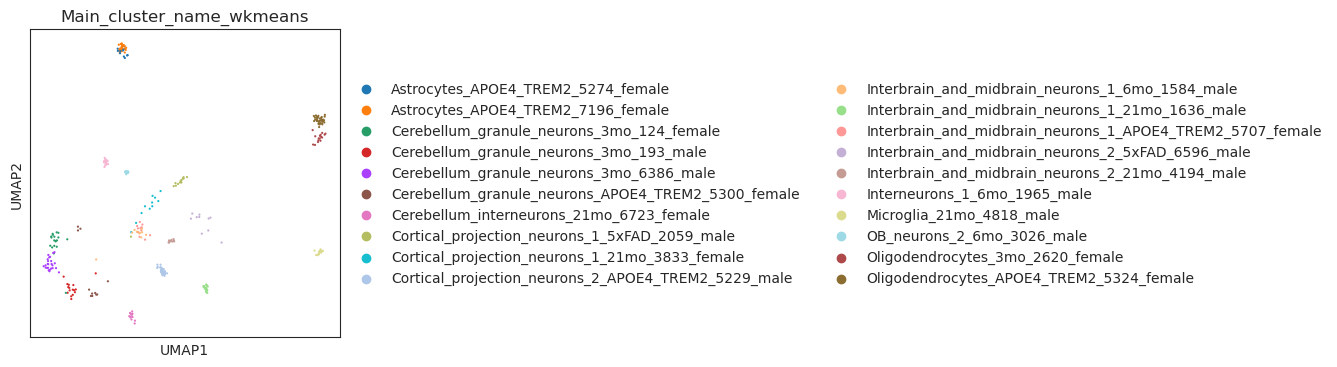

In [17]:
# Sample 3 random clusters from DT_anndata.obs.Main_cluster_name_wkmeans.value_counts()
plot_clusters = DT_anndata.obs.Main_cluster_name_wkmeans.value_counts().sample(20)
print(plot_clusters)

# Plot UMAP but just for two random clusters to see if they are separated 
subset_clust = DT_anndata[DT_anndata.obs.Main_cluster_name_wkmeans.isin(plot_clusters.index)]
sc.pl.umap(subset_clust, color="Main_cluster_name_wkmeans", ncols=1, cmap="tab20", s=10)

### Save dataframes containing cell mappings from new metacell to original individal cell BAM id

In [18]:
save_DT_cells = DT_anndata.obs[["sample", "Type", "primer", "Main_cluster_name", "Main_cluster_name_wkmeans"]]
# make new column called "cell_BAM_file_name" that is the same as "sample" but with .DT.bam at the end 
save_DT_cells["cell_BAM_file_name"] = save_DT_cells["sample"] + ".DT.bam"
save_DT_cells = save_DT_cells.drop_duplicates()
save_DT_cells.to_csv(WD + "DT_cells.csv", index=False)

/scratch/ipykernel_2302410/2715388844.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  save_DT_cells["cell_BAM_file_name"] = save_DT_cells["sample"] + ".DT.bam"


In [19]:
save_DT_cells["Cell_shortDT"] = save_DT_cells["sample"]
# Now we need to figure out the corresponding RH samples for each DT metacell 
rh_pair = cells[cells["Cell_shortDT"].isin(save_DT_cells["sample"])]

# Find all columsn are in common between rh_pair and save_DT_cells
common_columns = rh_pair.columns.intersection(save_DT_cells.columns)
print(common_columns)

Index(['Cell_shortDT', 'Type', 'Main_cluster_name'], dtype='object')


In [21]:
merged_test = save_DT_cells.merge(rh_pair, on=['Cell_shortDT'])

# Find rows in merged_test where Main_cluster_name_x and Main_cluster_name_y are not the same
merged_test[merged_test["Main_cluster_name_x"] != merged_test["Main_cluster_name_y"]][["Main_cluster_name_x", "Main_cluster_name_y"]]

# Drop Main_cluster_name_y from merged_test and rename Main_cluster_name_x to Main_cluster_name
merged_test = merged_test.drop(columns=["Main_cluster_name_y"])
merged_test = merged_test.rename(columns={"Main_cluster_name_x": "Main_cluster_name"})

# Now find the rows in merged_test where Type_x and Type_y are not the same
merged_test[merged_test["Type_x"] != merged_test["Type_y"]][["Type_x", "Type_y"]]
# Drop Type_y from merged_test and rename Type_x to Type
merged_test = merged_test.drop(columns=["Type_y"])
merged_test = merged_test.rename(columns={"Type_x": "Type"})

In [32]:
# Save also versions for anndata object removing individual cell ids and just keeping metacell info
# need to make sure that this contains the RH BAM file 
DT_anndata_meta = merged_test.copy()
DT_anndata_meta["RH_cell_BAM_file_name"] = DT_anndata_meta["Cell_random_hexamer"] + ".RH.bam"

# save as csv
DT_anndata_meta.to_csv(WD + "DT_w_RH_cells_anndata_meta.tsv", index=False)
DT_anndata_meta.head()

,sample,Type,primer,Main_cluster_name,Main_cluster_name_wkmeans,cell_BAM_file_name,Cell_shortDT,Cell_random_hexamer,UMI_count,Gene_count,...,umap_2,Louvain_cluster,Sex,Replicate_ID,Subcluster_id,Subcluster_umap_1,Subcluster_umap_2,Sub_cluster_num,pair_code,RH_cell_BAM_file_name
0,EasySci_001.AACCGATTGCAATCGAACTC,5xFAD,DT,Cerebellum_granule_neurons,Cerebellum_granule_neurons_5xFAD_6154_male,EasySci_001.AACCGATTGCAATCGAACTC.DT.bam,EasySci_001.AACCGATTGCAATCGAACTC,EasySci_001.AACCGATTGCATGCAATATG,558,379,...,4.792399,7,male,1,Cerebellum granule neurons_1,1.337663,-3.196105,1.0,1,EasySci_001.AACCGATTGCATGCAATATG.RH.bam
1,EasySci_001.AACCGATTGCACTCCGCCAA,3mo,DT,Interbrain_and_midbrain_neurons_2,Interbrain_and_midbrain_neurons_2_3mo_4694_male,EasySci_001.AACCGATTGCACTCCGCCAA.DT.bam,EasySci_001.AACCGATTGCACTCCGCCAA,EasySci_001.AACCGATTGCTTAGCAATAA,3180,1371,...,-3.935702,6,male,2,Interbrain and midbrain neurons 2_1,-0.875215,-2.433680,1.0,2,EasySci_001.AACCGATTGCTTAGCAATAA.RH.bam
2,EasySci_001.AACCGATTGCAGCGATCCGC,6mo,DT,Interbrain_and_midbrain_neurons_2,Interbrain_and_midbrain_neurons_2_6mo_790_male,EasySci_001.AACCGATTGCAGCGATCCGC.DT.bam,EasySci_001.AACCGATTGCAGCGATCCGC,EasySci_001.AACCGATTGCAGCTAAGGTA,3132,1657,...,-3.253150,31,male,1,Interbrain and midbrain neurons 2_2,2.808076,3.226601,2.0,3,EasySci_001.AACCGATTGCAGCTAAGGTA.RH.bam
3,EasySci_001.AACCGATTGCCATCCAGCCA,APOE4_TREM2,DT,Interbrain_and_midbrain_neurons_2,Interbrain_and_midbrain_neurons_2_APOE4_TREM2_...,EasySci_001.AACCGATTGCCATCCAGCCA.DT.bam,EasySci_001.AACCGATTGCCATCCAGCCA,EasySci_001.AACCGATTGCTCTCCTATAA,10028,3436,...,-3.673076,30,male,2,Interbrain and midbrain neurons 2_3,1.555948,0.093578,3.0,4,EasySci_001.AACCGATTGCTCTCCTATAA.RH.bam
4,EasySci_001.AACCGATTGCCCAGGCTCTT,6mo,DT,Oligodendrocyte_progenitor_cells,Oligodendrocyte_progenitor_cells_6mo_3650_male,EasySci_001.AACCGATTGCCCAGGCTCTT.DT.bam,EasySci_001.AACCGATTGCCCAGGCTCTT,EasySci_001.AACCGATTGCCGCCTCGAAC,953,610,...,0.636785,47,male,1,Oligodendrocyte progenitor cells_1,3.020408,-0.754258,1.0,5,EasySci_001.AACCGATTGCCGCCTCGAAC.RH.bam


In [35]:
DT_anndata_meta.columns[24]

'RH_cell_BAM_file_name'

In [36]:
print(f"The number of metacells in DT_anndata_meta is {len(DT_anndata_meta)}")

The number of metacells in DT_anndata_meta is 503348


In [33]:
print(WD)

/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/


# Save the Anndata objects to file 

## Make a metacell expression dataset combining all the gene reads across cells in the same metacell 

### Create Metacell Dataset by Aggregating Gene Counts

Here, we'll create a new AnnData object where each observation is a metacell.

1.  **Aggregate Gene Expression**: We'll sum the raw gene counts for all individual cells that belong to the same metacell (`Main_cluster_name_wkmeans`). Instead of looping, we'll use efficient sparse matrix multiplication.
2.  **Create Metacell Metadata**: We'll create a new metadata (`.obs`) dataframe. Since `Type`, `kmeans_cluster`, `Main_cluster_name`, and `Sex` are constant within each metacell group, we'll carry over these attributes to the new metacell observations.
3.  **Construct Final AnnData Object**: We'll combine the aggregated expression matrix, the new metadata, and the original gene information (`.var`) to create a final `AnnData` object for the metacells.

In [23]:
DT_anndata.layers["raw"].data.max()

10301

In [24]:
from scipy.sparse import csr_matrix

# Get the metacell labels
metacell_labels = DT_anndata.obs['Main_cluster_name_wkmeans']

# Get unique metacells and their integer codes. `np.unique` sorts the unique_metacells.
unique_metacells, metacell_codes = np.unique(metacell_labels, return_inverse=True)

# Create a sparse "grouping" matrix. This matrix will have dimensions
# (n_original_cells, n_metacells) and will be used to sum counts.
grouping_matrix = csr_matrix((np.ones(len(metacell_codes)), 
                              (np.arange(len(metacell_codes)), metacell_codes)),
                             shape=(DT_anndata.n_obs, len(unique_metacells)))

# Sum expression per metacell by multiplying the transpose of the grouping matrix
# with the raw counts matrix. We use the 'raw' layer which contains filtered, unnormalized counts.
# The dimensions are: (n_metacells, n_original_cells) @ (n_original_cells, n_genes) -> (n_metacells, n_genes)
metacell_X = (grouping_matrix.T @ DT_anndata.layers['raw'])

# Create the new metadata for the metacells.
# We group by the metacell label and take the first entry for each column.
# This works because the columns we are interested in should be constant within each metacell group.
# The resulting DataFrame will be indexed by `Main_cluster_name_wkmeans`, sorted alphabetically,
# which matches the order of `unique_metacells`.
metacell_obs = DT_anndata.obs.groupby('Main_cluster_name_wkmeans').first()

# You wanted to keep 'Type', 'kmeans_cluster', 'Main_cluster_name', and 'Sex'.
columns_to_keep = ['Type', 'kmeans_cluster', 'Main_cluster_name', 'Sex']
metacell_obs_final = metacell_obs[columns_to_keep]

# Now, create the new AnnData object for the metacells.
# The observations (.obs) are the metacell metadata, and the variables (.var) are the original gene annotations.
metacell_anndata = sc.AnnData(X=metacell_X,
                              obs=metacell_obs_final,
                              var=DT_anndata.var)

print("Created DT metacell anndata object:")
print(metacell_anndata)

metacell_anndata.obs["Main_cluster_name_wkmeans"] = metacell_anndata.obs.index
metacell_anndata.obs["cell_id_index"] = range(metacell_anndata.shape[0])

# remove and rest index in metacell_anndata
metacell_anndata.obs.reset_index(drop=True, inplace=True)

Created DT metacell anndata object:
AnnData object with n_obs × n_vars = 26093 × 43639
    obs: 'Type', 'kmeans_cluster', 'Main_cluster_name', 'Sex'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'is_variable'


In [25]:
# Store unfiltered matrix
metacell_anndata.layers["raw"] = metacell_anndata.X.copy()
metacell_anndata 

AnnData object with n_obs × n_vars = 26093 × 43639
    obs: 'Type', 'kmeans_cluster', 'Main_cluster_name', 'Sex', 'Main_cluster_name_wkmeans', 'cell_id_index'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'is_variable'
    layers: 'raw'

In [26]:
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix, csc_matrix
import numpy as np

# Normalize and transform
sc.pp.normalize_total(metacell_anndata, target_sum=1e4)
sc.pp.log1p(metacell_anndata)

# Use CPU-based PCA for sparse matrices
print("Starting PCA computation...")
pca_model = PCA(n_components=50, random_state=42)

# Convert to dense if needed (for very large matrices, consider using TruncatedSVD instead)
if isinstance(metacell_anndata.X, (csr_matrix, csc_matrix)):
    # For large sparse matrices, use TruncatedSVD instead of PCA
    from sklearn.decomposition import TruncatedSVD
    pca_model = TruncatedSVD(n_components=50, random_state=42)
    pca_result = pca_model.fit_transform(metacell_anndata.X)
else:
    pca_result = pca_model.fit_transform(metacell_anndata.X)

metacell_anndata.obsm["X_pca"] = pca_result
print("PCA completed!")

# Neighbors and UMAP
sc.pp.neighbors(metacell_anndata, n_neighbors=15, use_rep="X_pca")
print("Done computing neighbors!")
sc.tl.umap(metacell_anndata, method="rapids")
print("Done with UMAP!")

Starting PCA computation...
PCA completed!
Done computing neighbors!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/tools/_umap.py:233: FutureWarning: `method='rapids'` is deprecated. Use `rapids_singlecell.tl.louvain` instead.
  warnings.warn(msg, FutureWarning)


Done with UMAP!


In [27]:
metacell_anndata

AnnData object with n_obs × n_vars = 26093 × 43639
    obs: 'Type', 'kmeans_cluster', 'Main_cluster_name', 'Sex', 'Main_cluster_name_wkmeans', 'cell_id_index'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'is_variable'
    uns: 'log1p', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'raw'
    obsp: 'distances', 'connectivities'

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-pac

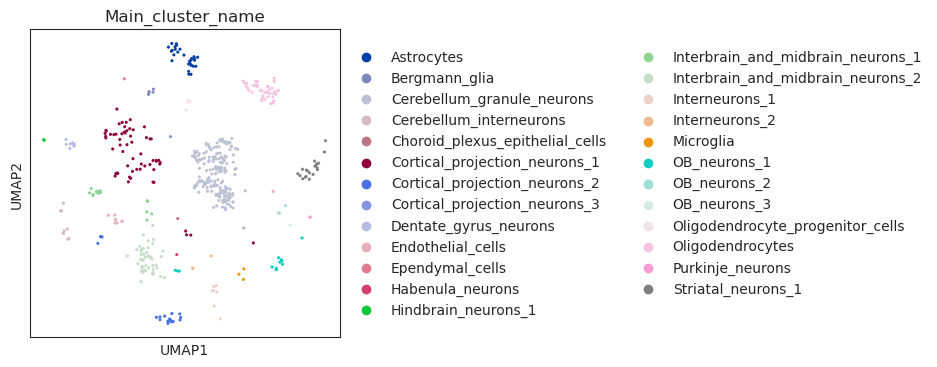

In [29]:
# Plot umap for 20 random metacells
plot_clusters = metacell_anndata.obs["Main_cluster_name_wkmeans"].value_counts().sample(500).index
subset_clust = metacell_anndata[metacell_anndata.obs["Main_cluster_name_wkmeans"].isin(plot_clusters)]

sc.pl.umap(
    subset_clust, 
    color="Main_cluster_name", 
    ncols=1,
    s=20, 
    legend_loc='right margin'
)

In [30]:
# save metacell_anndata to file 
metacell_anndata.write_h5ad(WD + "metacell_RT_anndata.h5ad", compression="lzf")
print(f"Done saving metacell_anndata to file: {WD + 'metacell_RT_anndata.h5ad'}")

Done saving metacell_anndata to file: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/metacell_RT_anndata.h5ad


In [31]:
metacell_anndata

AnnData object with n_obs × n_vars = 26093 × 43639
    obs: 'Type', 'kmeans_cluster', 'Main_cluster_name', 'Sex', 'Main_cluster_name_wkmeans', 'cell_id_index'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'is_variable'
    uns: 'log1p', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'raw'
    obsp: 'distances', 'connectivities'